In [4]:
import pandas as pd
# pd.read_csv('gab.csv')
# pd.read_excel('gab.xlsx')

In [6]:
ddf = pd.read_csv('./data_/구매상품.csv')

In [7]:
demo = pd.read_csv('./data_/DEMO.txt', encoding="cp949", dtype={'거주지역': str} )
demo

,고객번호,성별,연령대,거주지역
0,1,M,60세이상,060
1,2,M,60세이상,100
2,3,M,60세이상,033
3,4,F,60세이상,016
4,5,M,60세이상,100
...,...,...,...,...
19378,19379,F,20세~24세,069
19379,19380,F,20세~24세,039
19380,19381,F,40세~44세,460
19381,19382,F,45세~49세,460


In [8]:
post = pd.read_excel('./data_/list.xlsx', sheet_name = "지역코드", dtype={'우편번호': str} )
post

,우편번호,시도
0,01000,서울특별시
1,01000,서울특별시
2,01000,서울특별시
3,01000,서울특별시
4,01000,서울특별시
...,...,...
311733,63644,제주특별자치도
311734,63644,제주특별자치도
311735,63644,제주특별자치도
311736,63644,제주특별자치도


In [9]:
def classify(x):
    if (x == '20세~24세') or (x == '25세~29세'): 
        return '20대'
    elif (x == '30세~34세') or (x == '35세~39세'):
        return '30대'
    elif (x == '40세~44세') or (x == '45세~49세'):
        return '40대'
    elif (x == '50세~54세') or (x == '55세~59세'):
        return '50대'
    else:
        return x
        
demo['연령구분'] = demo['연령대'].apply(classify)


#comparison = post['우편번호'].str[:3] == demo['거주지역']

post['key_3'] = post['우편번호'].astype(str).str[:3]
demo_new = pd.merge(demo, post[['key_3','시도']], left_on='거주지역', right_on='key_3', how='left')
demo_new.drop(columns =  ['key_3'], inplace = True)
demo_unique = demo_new.drop_duplicates(subset=['고객번호'])
demo_new = demo_unique.reset_index()

In [10]:
# demo_new.drop(columns = 'index', inplace = True)
demo_new

,index,고객번호,성별,연령대,거주지역,연령구분,시도
0,0,1,M,60세이상,060,60세이상,서울특별시
1,708,2,M,60세이상,100,60세이상,경기도
2,2163,3,M,60세이상,033,60세이상,서울특별시
3,2760,4,F,60세이상,016,60세이상,서울특별시
4,3219,5,M,60세이상,100,60세이상,경기도
...,...,...,...,...,...,...,...
19378,18586276,19379,F,20세~24세,069,20대,서울특별시
19379,18586949,19380,F,20세~24세,039,20대,서울특별시
19380,18587518,19381,F,40세~44세,460,40대,부산광역시
19381,18588342,19382,F,45세~49세,460,40대,부산광역시


In [11]:
merged_purchase = pd.merge(demo_new, ddf[['고객번호', '소분류코드']], on = '고객번호', how ='left')
merged_purchase

,index,고객번호,성별,연령대,거주지역,연령구분,시도,소분류코드
0,0,1,M,60세이상,060,60세이상,서울특별시,A020105
1,0,1,M,60세이상,060,60세이상,서울특별시,A040214
2,0,1,M,60세이상,060,60세이상,서울특별시,A010302
3,0,1,M,60세이상,060,60세이상,서울특별시,A010404
4,0,1,M,60세이상,060,60세이상,서울특별시,A010501
...,...,...,...,...,...,...,...,...
28593025,18589166,19383,F,25세~29세,500,20대,경상남도,B740102
28593026,18589166,19383,F,25세~29세,500,20대,경상남도,B740402
28593027,18589166,19383,F,25세~29세,500,20대,경상남도,A060167
28593028,18589166,19383,F,25세~29세,500,20대,경상남도,A040254


In [12]:
df2 = pd.read_excel('./data_/list.xlsx', sheet_name='상품분류')

df2

,제휴사,대분류코드,중분류코드,소분류코드,중분류명,소분류명
0,A,1,101,A010101,일용잡화,위생세제
1,A,1,101,A010102,일용잡화,휴지류
2,A,1,101,A010103,일용잡화,뷰티상품
3,A,1,101,A010104,일용잡화,일용잡화
4,A,1,101,A010105,일용잡화,세트상품
...,...,...,...,...,...,...
4381,D,8,802,D080204,아이메이크업,아이섀도우
4382,D,8,802,D080205,아이메이크업,메이크업세트
4383,D,8,803,D080301,립메이크업,립스틱/립라이너
4384,D,8,803,D080302,립메이크업,립글로즈/틴트


In [13]:
final = pd.merge(merged_purchase, df2[['소분류명', '소분류코드', '중분류명']], on = '소분류코드', how='left')

final

,index,고객번호,성별,연령대,거주지역,연령구분,시도,소분류코드,소분류명,중분류명
0,0,1,M,60세이상,060,60세이상,서울특별시,A020105,스타킹(특정),섬유잡화
1,0,1,M,60세이상,060,60세이상,서울특별시,A040214,캐릭터캐주얼,캐주얼
2,0,1,M,60세이상,060,60세이상,서울특별시,A010302,유제품,축산가공
3,0,1,M,60세이상,060,60세이상,서울특별시,A010404,농산가공,농산물
4,0,1,M,60세이상,060,60세이상,서울특별시,A010501,생선,수산품
...,...,...,...,...,...,...,...,...,...,...
28593025,18589166,19383,F,25세~29세,500,20대,경상남도,B740102,컵라면,라면
28593026,18589166,19383,F,25세~29세,500,20대,경상남도,B740402,즉석밥류,밥죽류
28593027,18589166,19383,F,25세~29세,500,20대,경상남도,A060167,스포츠화,스포츠
28593028,18589166,19383,F,25세~29세,500,20대,경상남도,A040254,영스트리트,캐주얼


In [82]:
final.head(500).to_csv('final2.txt')

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

In [15]:
final.groupby(['시도','연령구분'])['중분류명'].value_counts().groupby(level=[0, 1]).head(5)
result = final.groupby(['시도','연령구분'])['중분류명'].value_counts().groupby(level=[0, 1]).head(5).reset_index(name='count')

result 

,시도,연령구분,중분류명,count
0,강원특별자치도,20대,라면,540
1,강원특별자치도,20대,스낵,535
2,강원특별자치도,20대,탄산음료,513
3,강원특별자치도,20대,아이스크림,482
4,강원특별자치도,20대,맥주,478
...,...,...,...,...
445,충청북도,60세이상,맥주,1019
446,충청북도,60세이상,스낵,700
447,충청북도,60세이상,라면,510
448,충청북도,60세이상,두부,473


In [16]:
# 1. 데이터 준비 및 정렬 (result는 이전에 groupby로 만든 데이터프레임 이름입니다)
# 'result' 대신 실제 가지고 계신 데이터프레임 변수명을 넣으세요.
top3_counts = result.sort_values(['시도', '연령구분', 'count'], ascending=[True, True, False])

# 2. 각 시도/연령별 상위 3개 추출
top3_counts = top3_counts.groupby(['시도', '연령구분']).head(3)

# 3. 고유한 시도 목록 가져오기
sido_list = top3_counts['시도'].unique()
sido_list

<StringArray>
['강원특별자치도',     '경기도',    '경상남도',    '경상북도',   '광주광역시',   '대구광역시',   '대전광역시',
   '부산광역시',   '서울특별시', '세종특별자치시',   '울산광역시',   '인천광역시',    '전라남도', '전북특별자치도',
 '제주특별자치도',    '충청남도',    '충청북도']
Length: 17, dtype: str

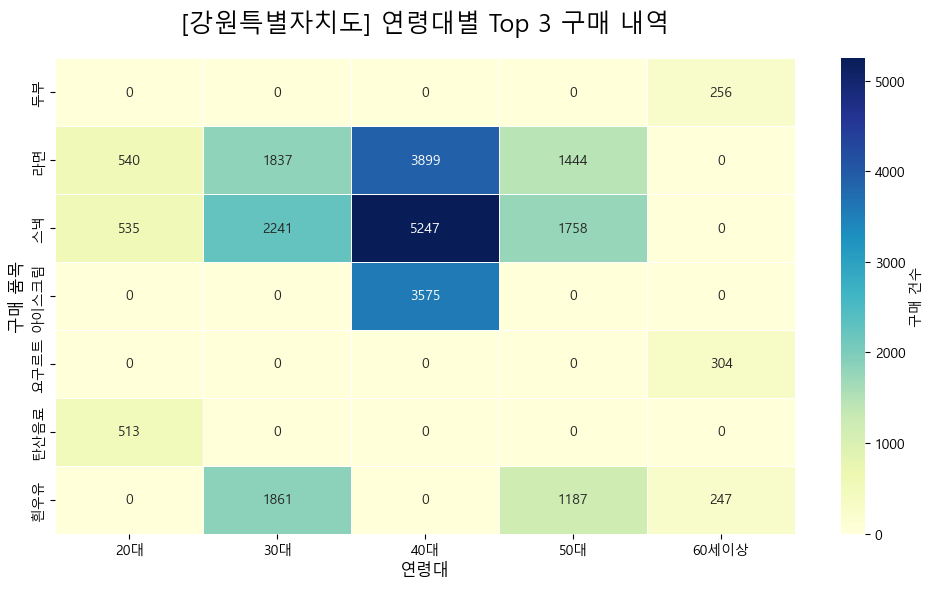

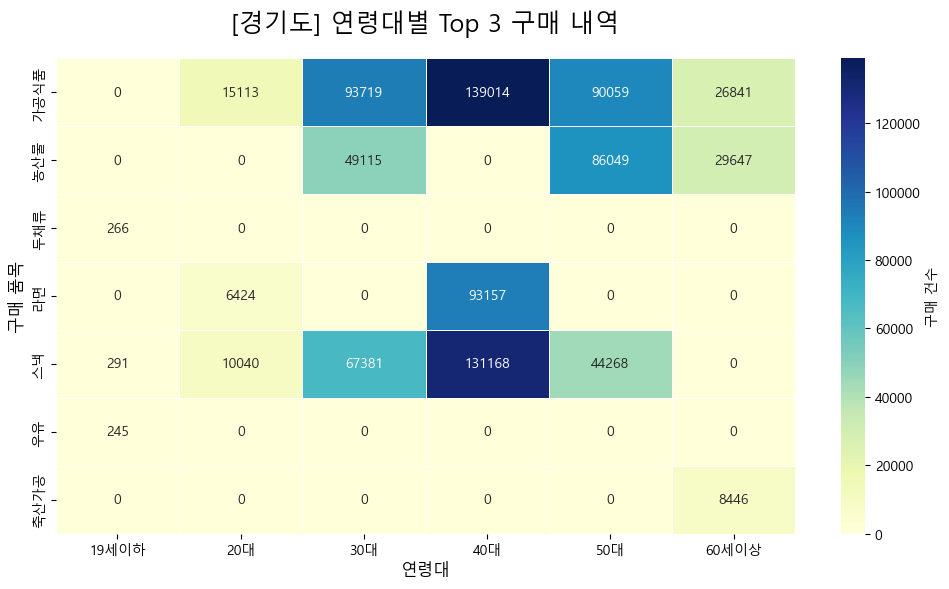

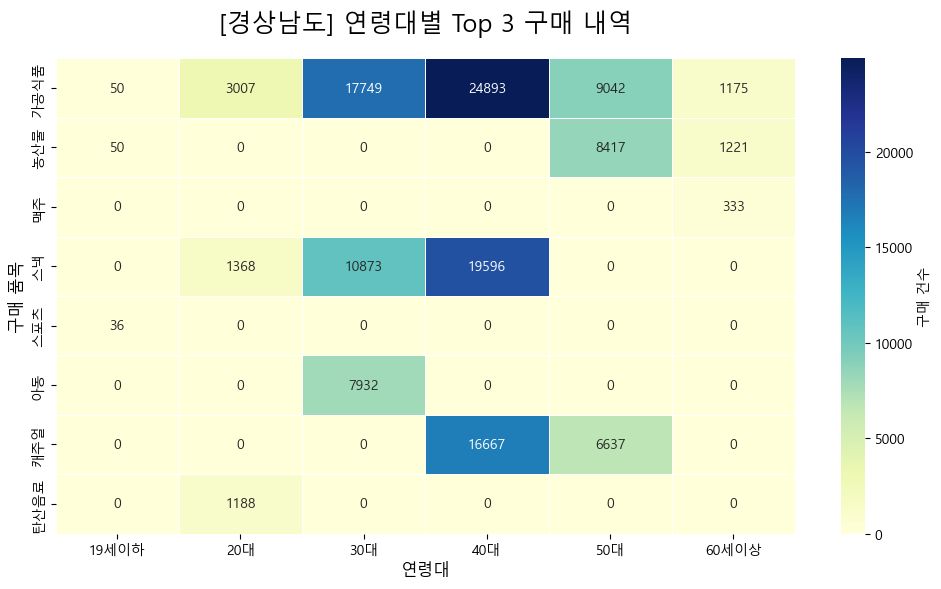

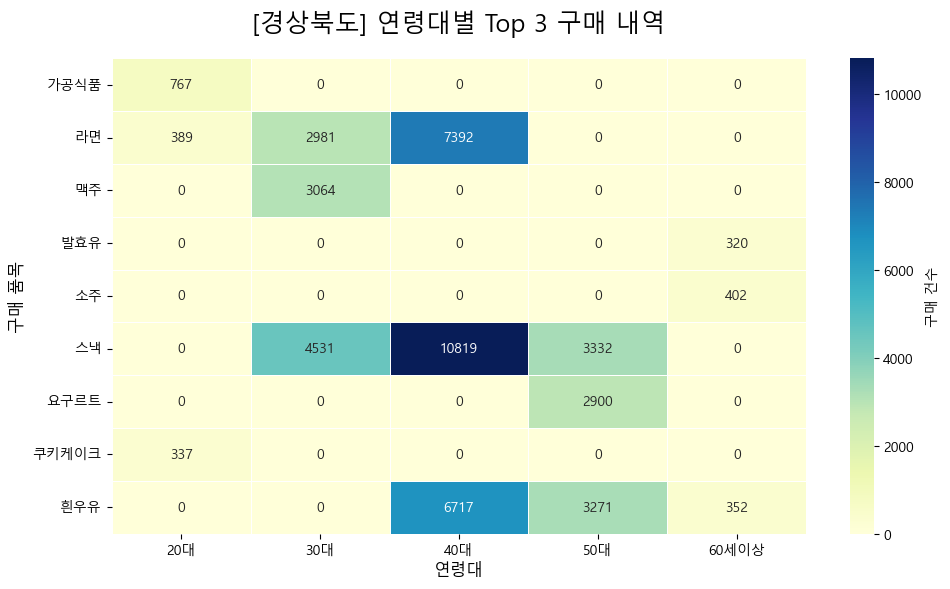

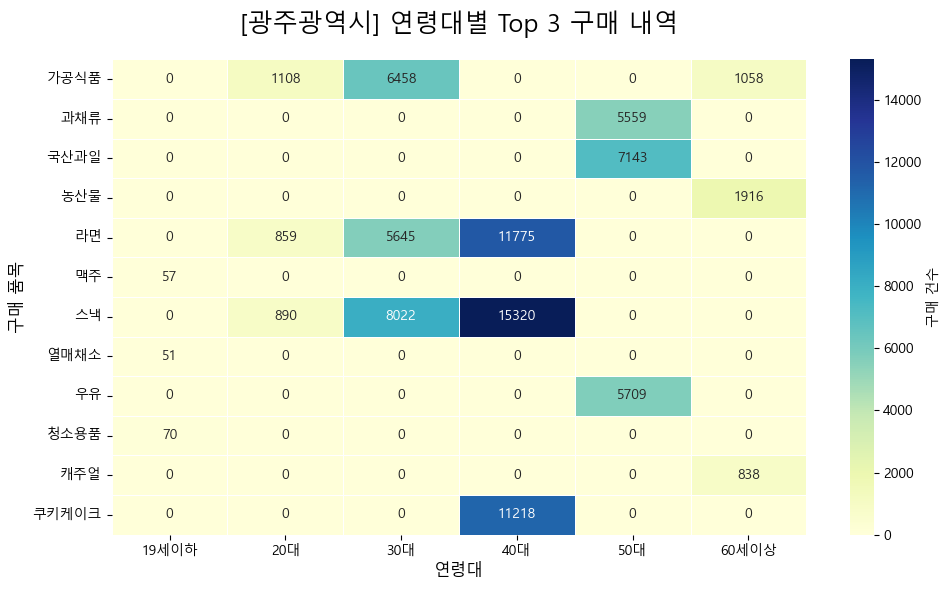

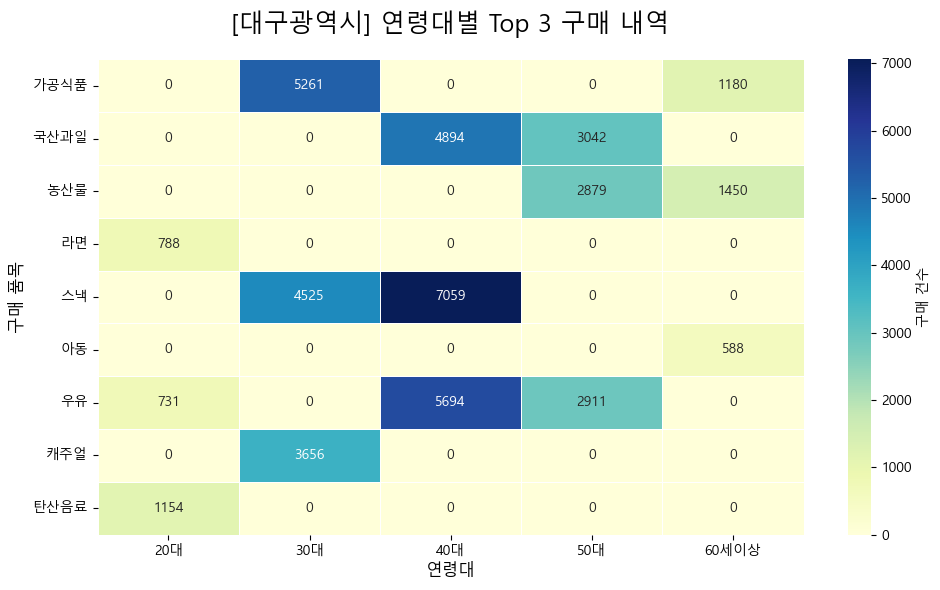

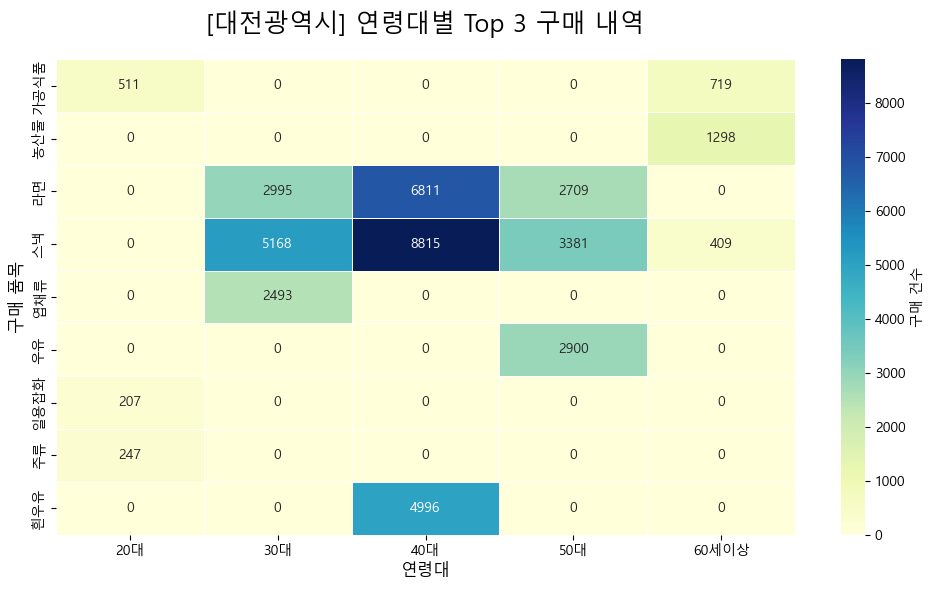

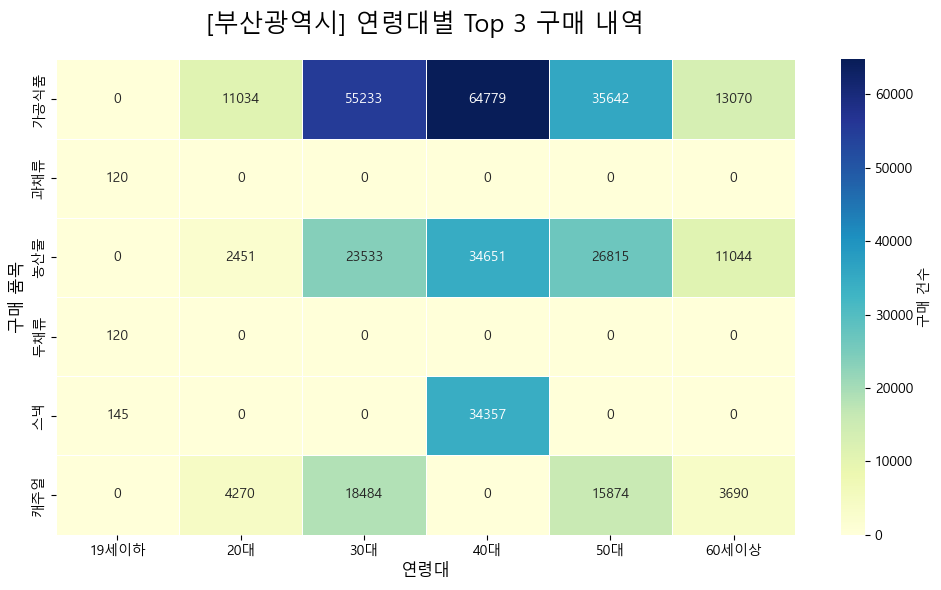

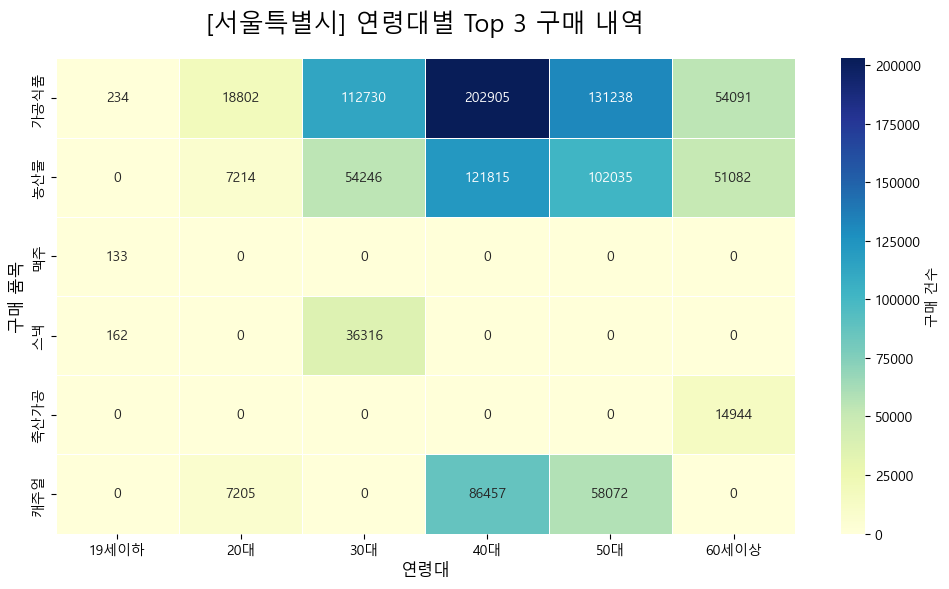

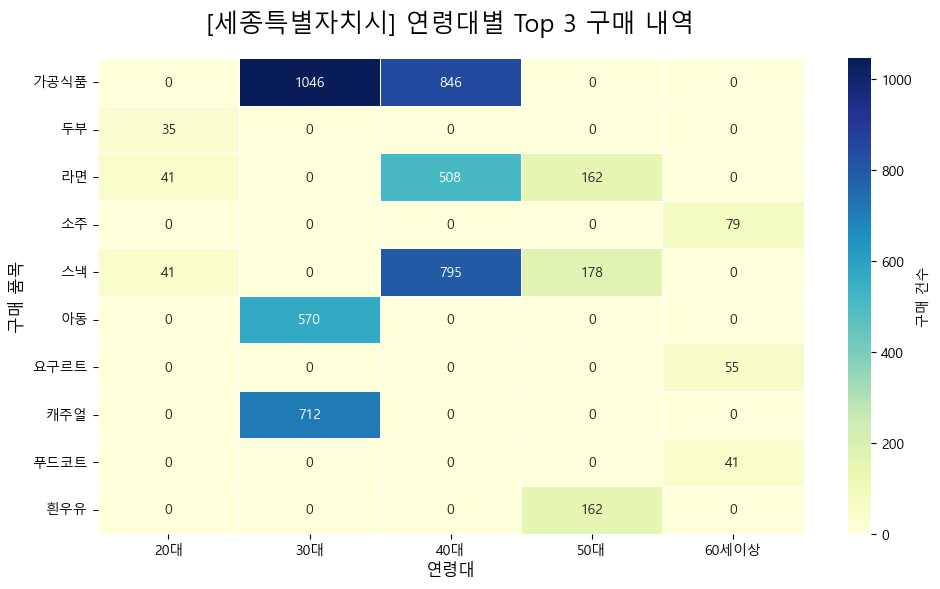

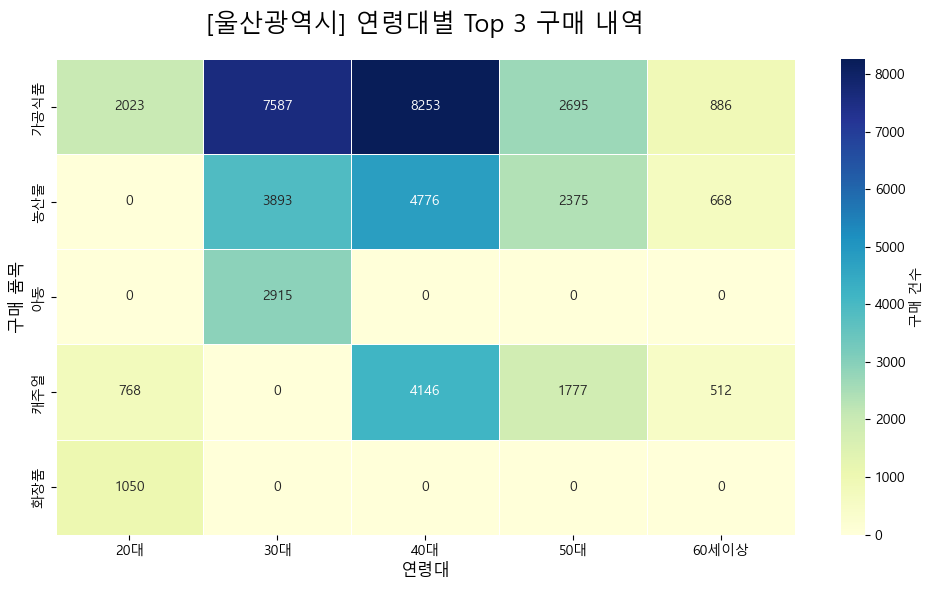

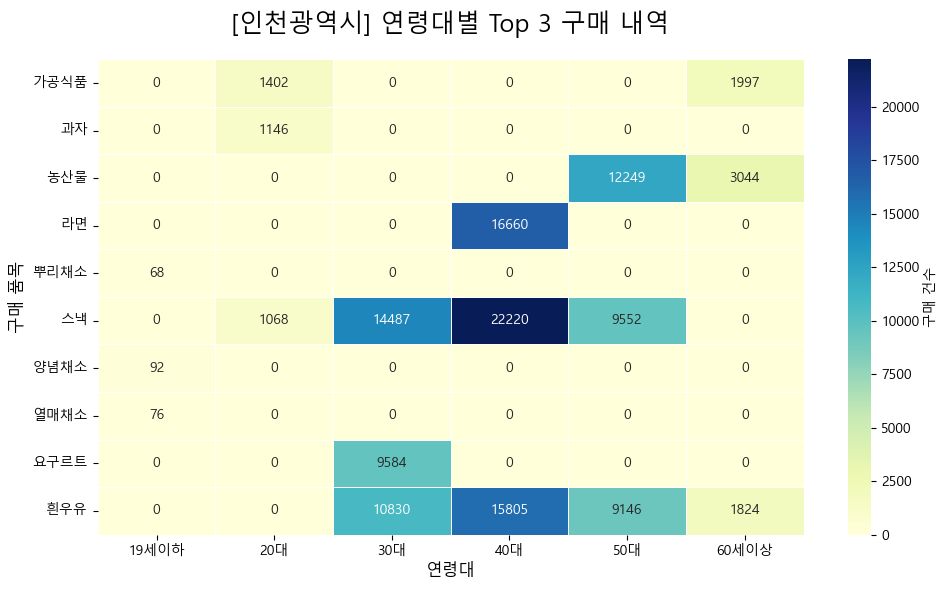

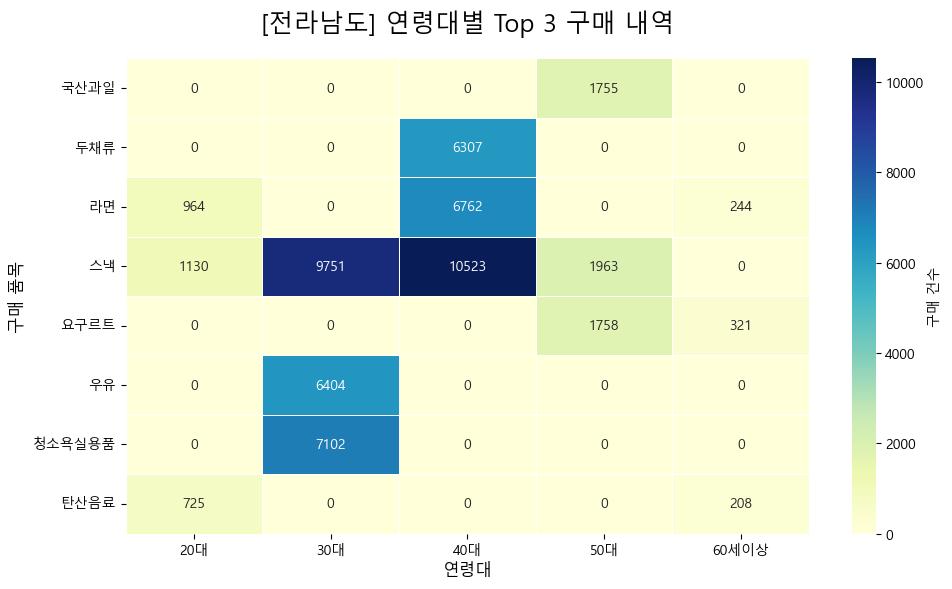

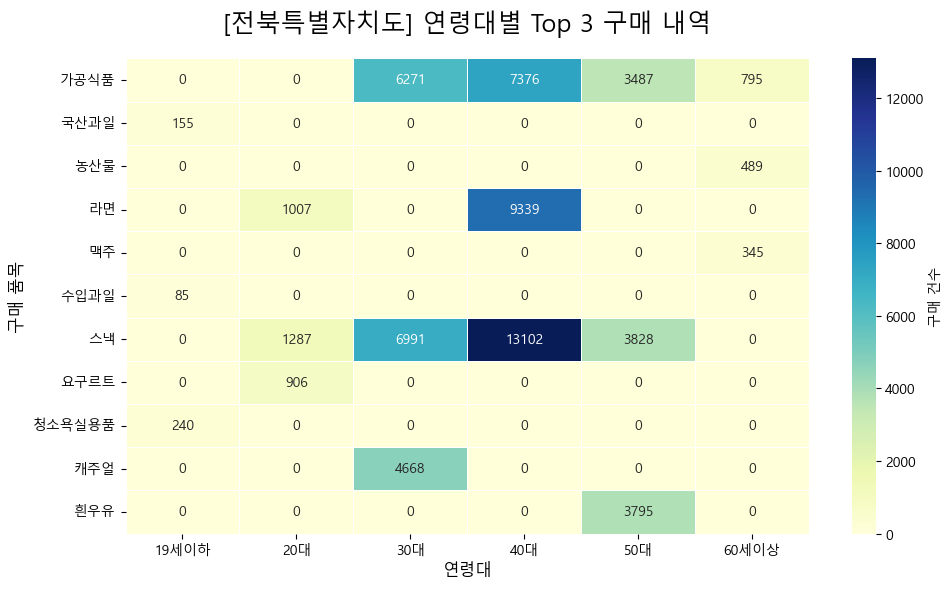

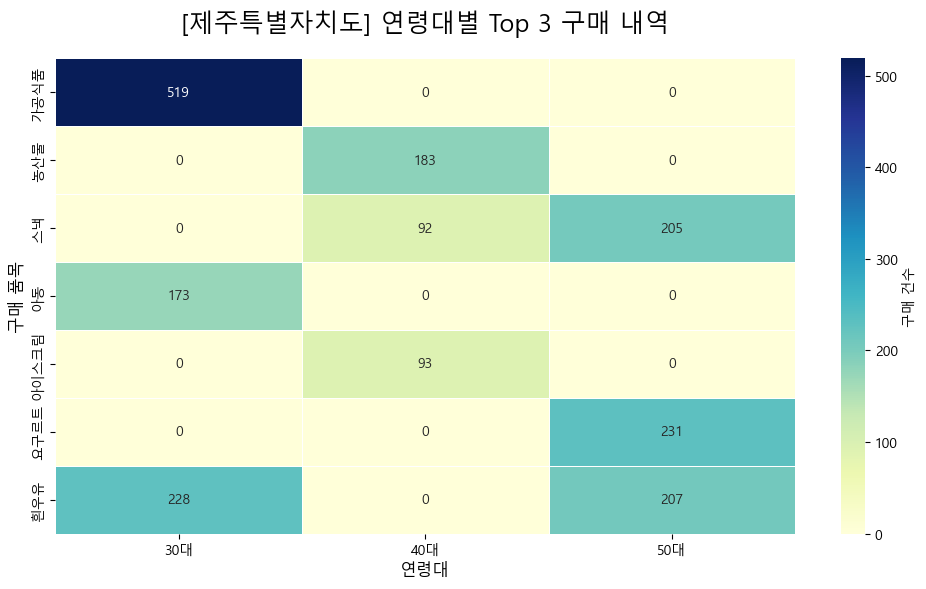

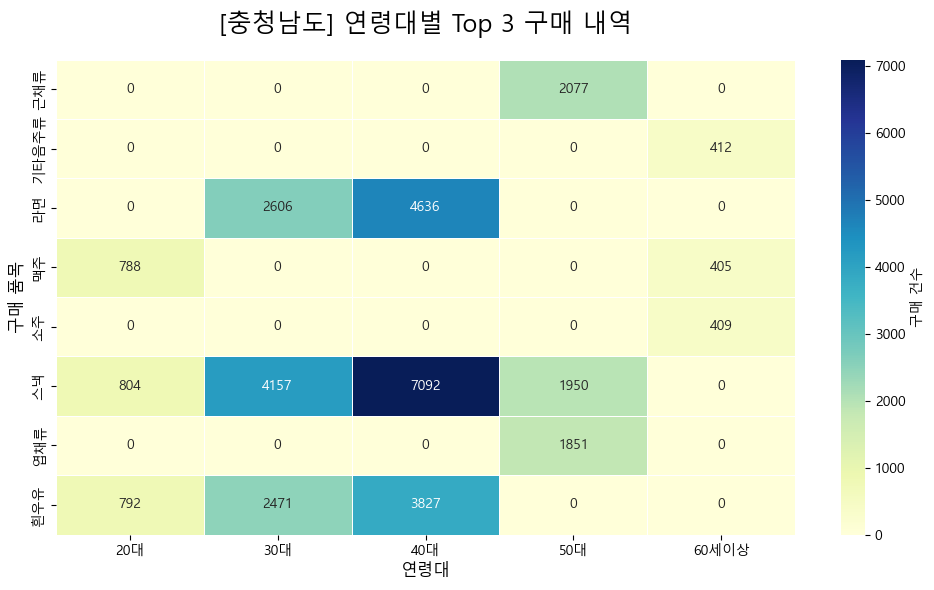

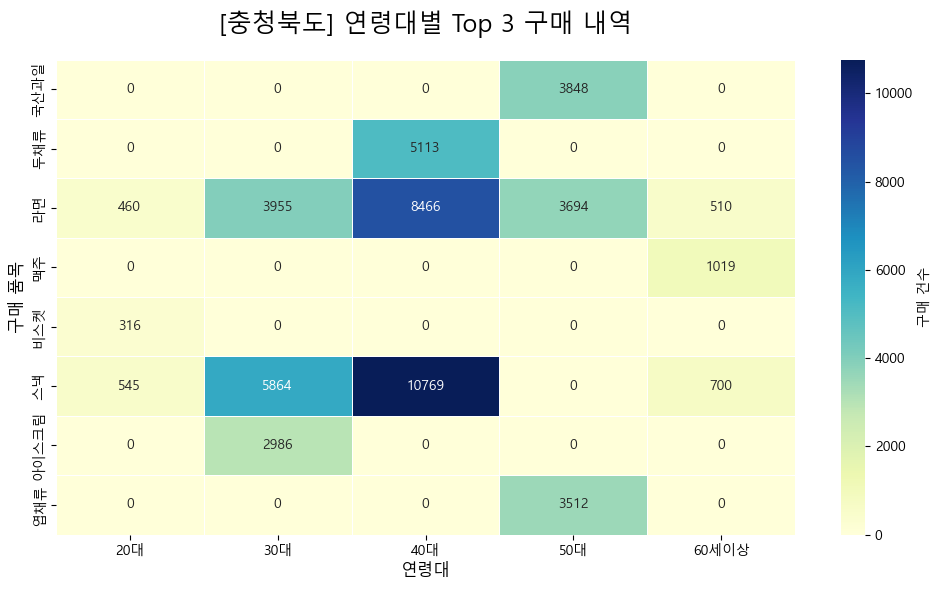

In [70]:
# 4. 반복문을 돌며 시도별 히트맵 생성
for sido in sido_list:
    # 해당 시도 데이터만 필터링
    df_sample = top3_counts[top3_counts['시도'] == sido]
    
    # 피벗 테이블 생성 (품목을 세로축, 연령을 가로축)
    # 40대와 60대(60세이상)만 보고 싶다면 여기서 필터링을 추가할 수 있습니다.
    pivot_df = df_sample.pivot(index='중분류명', columns='연령구분', values='count')
    
    # 결측치 처리
    pivot_df = pivot_df.fillna(0)
    
    # 그래프 그리기
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        pivot_df, 
        annot=True,      # 숫자 표시
        fmt=".0f",        # 소수점 없이 표시
        cmap="YlGnBu",    # 색상 테마
        linewidths=.5,    # 칸 사이 간격
        cbar_kws={'label': '구매 건수'}
    )
    
    plt.title(f'[{sido}] 연령대별 Top 3 구매 내역', fontsize=18, pad=20)
    plt.ylabel('구매 품목', fontsize=12)
    plt.xlabel('연령대', fontsize=12)
    plt.tight_layout()
    
    plt.show() # 각 시도별로 독립된 그래프 출력

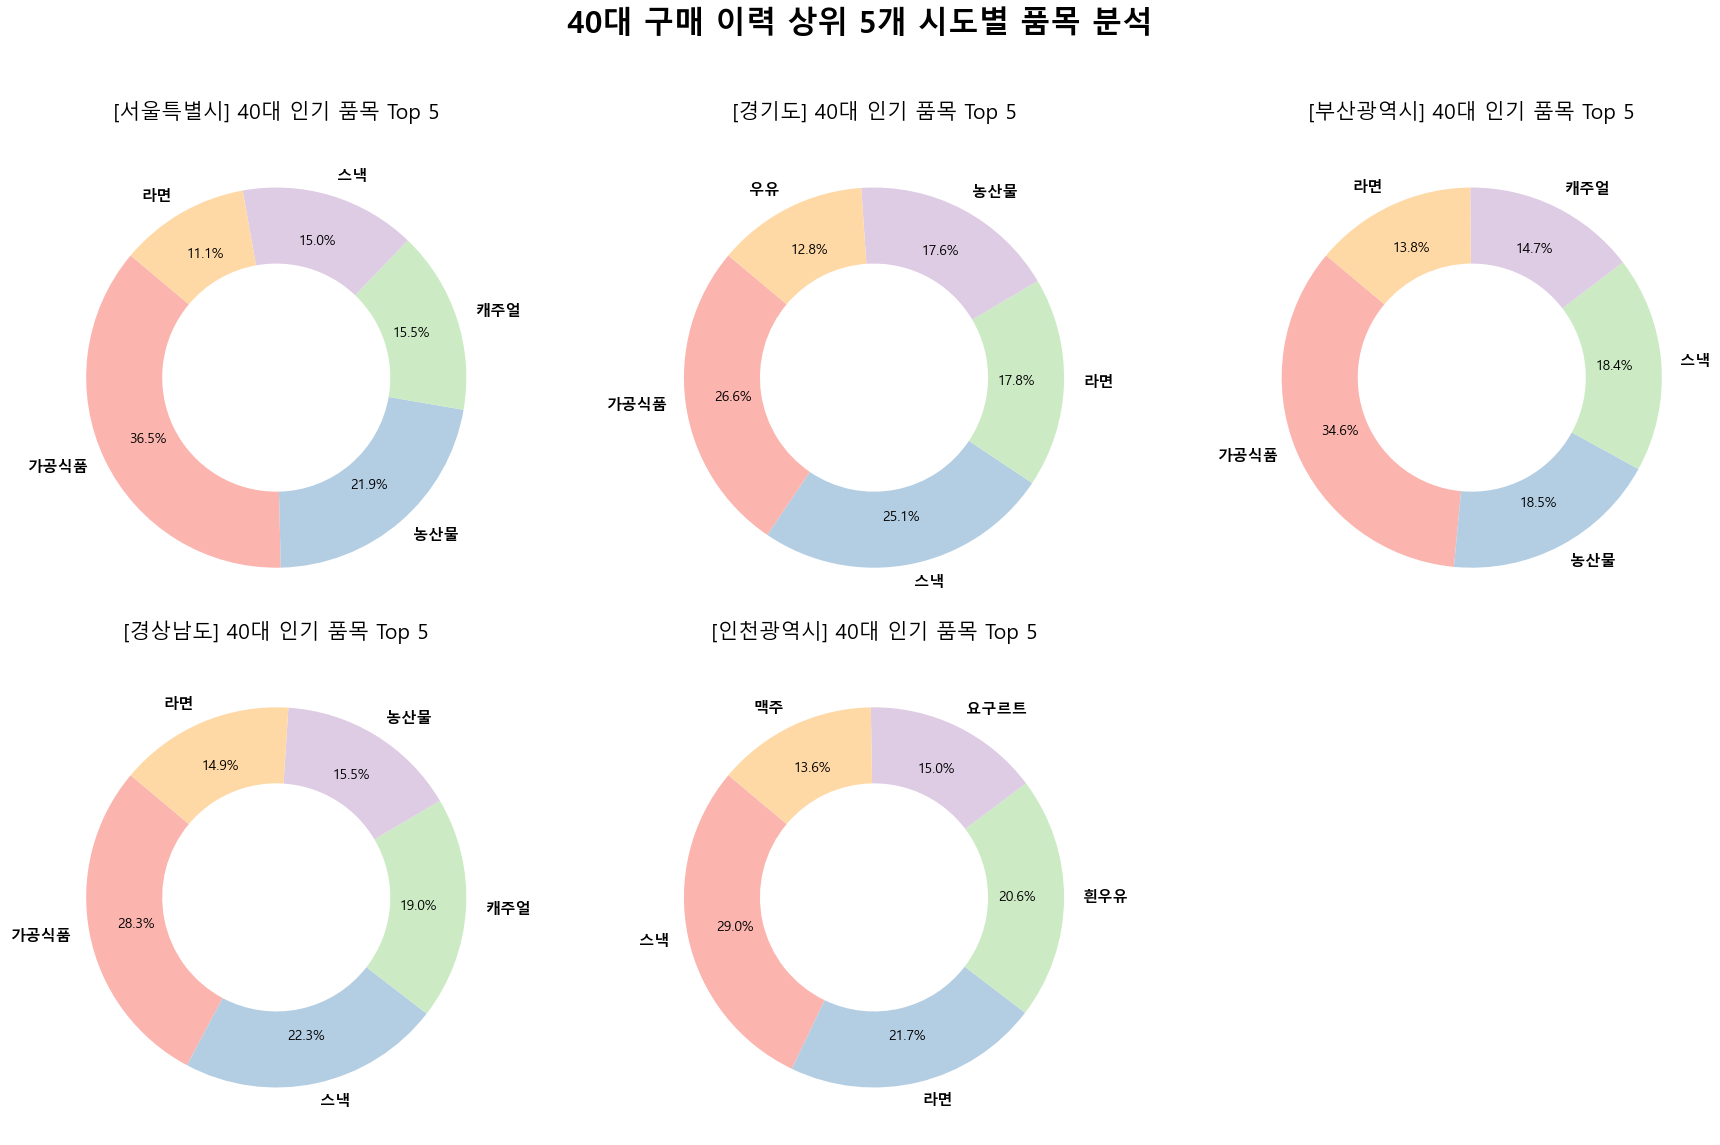

In [74]:
# 2. 40대 데이터 필터링 (이미 만들어진 result 데이터프레임 활용)
res_40 = result[result['연령구분'].str.contains('40대')]

# 3. 40대 총 구매 건수 기준 상위 5개 시도 리스트 추출
top5_sido = res_40.groupby('시도')['count'].sum().sort_values(ascending=False).head(5).index

# 4. 시각화 설정 (2행 3열 레이아웃)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # 2D 배열을 1D로 풀어서 반복문 돌리기 편하게 함

for i, sido in enumerate(top5_sido):
    # 해당 시도의 40대 데이터 중 품목 상위 5개 추출
    df_plot = res_40[res_40['시도'] == sido].sort_values('count', ascending=False).head(5)
    
    # 도넛 차트 그리기
    wedges, texts, autotexts = axes[i].pie(
        df_plot['count'], 
        labels=df_plot['중분류명'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Pastel1.colors,
        pctdistance=0.75,
        wedgeprops={'width': 0.4} # 도넛의 두께 설정 (0.4 정도가 적당)
    )
    
    # 텍스트 스타일 조정
    plt.setp(texts, size=11, fontweight='bold')
    plt.setp(autotexts, size=10, color='black')
    
    axes[i].set_title(f'[{sido}] 40대 인기 품목 Top 5', fontsize=15, pad=15)

# 사용하지 않는 마지막 6번째 서브플롯(빈 칸) 삭제
fig.delaxes(axes[5])

plt.suptitle('40대 구매 이력 상위 5개 시도별 품목 분석', fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [73]:
result

,시도,연령구분,중분류명,count
0,강원특별자치도,20대,라면,540
1,강원특별자치도,20대,스낵,535
2,강원특별자치도,20대,탄산음료,513
3,강원특별자치도,20대,아이스크림,482
4,강원특별자치도,20대,맥주,478
...,...,...,...,...
445,충청북도,60세이상,맥주,1019
446,충청북도,60세이상,스낵,700
447,충청북도,60세이상,라면,510
448,충청북도,60세이상,두부,473


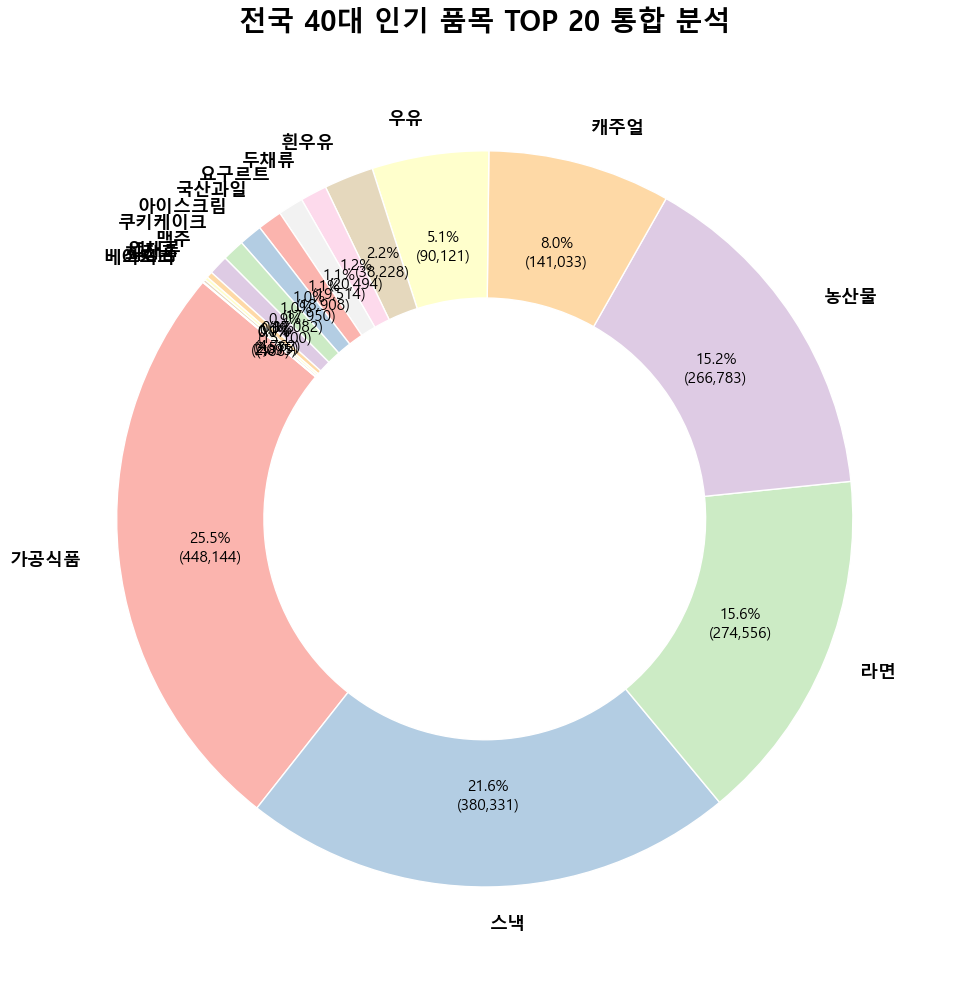

In [72]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 40대 데이터 전국 단위 합계 계산
# 시도 구분 없이 '중분류명'으로 그룹화하여 count를 모두 더합니다.
res_40 = result[result['연령구분'].str.contains('40대')]

res_40_total = res_40.groupby('중분류명')['count'].sum().sort_values(ascending=False).head(20)

# 3. 단일 도넛 차트 시각화
plt.figure(figsize=(10, 10))

# 도넛 차트 그리기
wedges, texts, autotexts = plt.pie(
    res_40_total, 
    labels=res_40_total.index, 
    # 천 단위 콤마와 퍼센트를 동시에 표시 (함수 활용)
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(res_40_total)/100):,})', 
    startangle=140, 
    colors=plt.cm.Pastel1.colors,
    pctdistance=0.75,
    wedgeprops={'width': 0.4, 'edgecolor': 'w'}
)

# 텍스트 스타일 지정
plt.setp(texts, size=13, fontweight='bold')
plt.setp(autotexts, size=11, color='black', fontweight='normal')

plt.title('전국 40대 인기 품목 TOP 20 통합 분석', fontsize=20, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

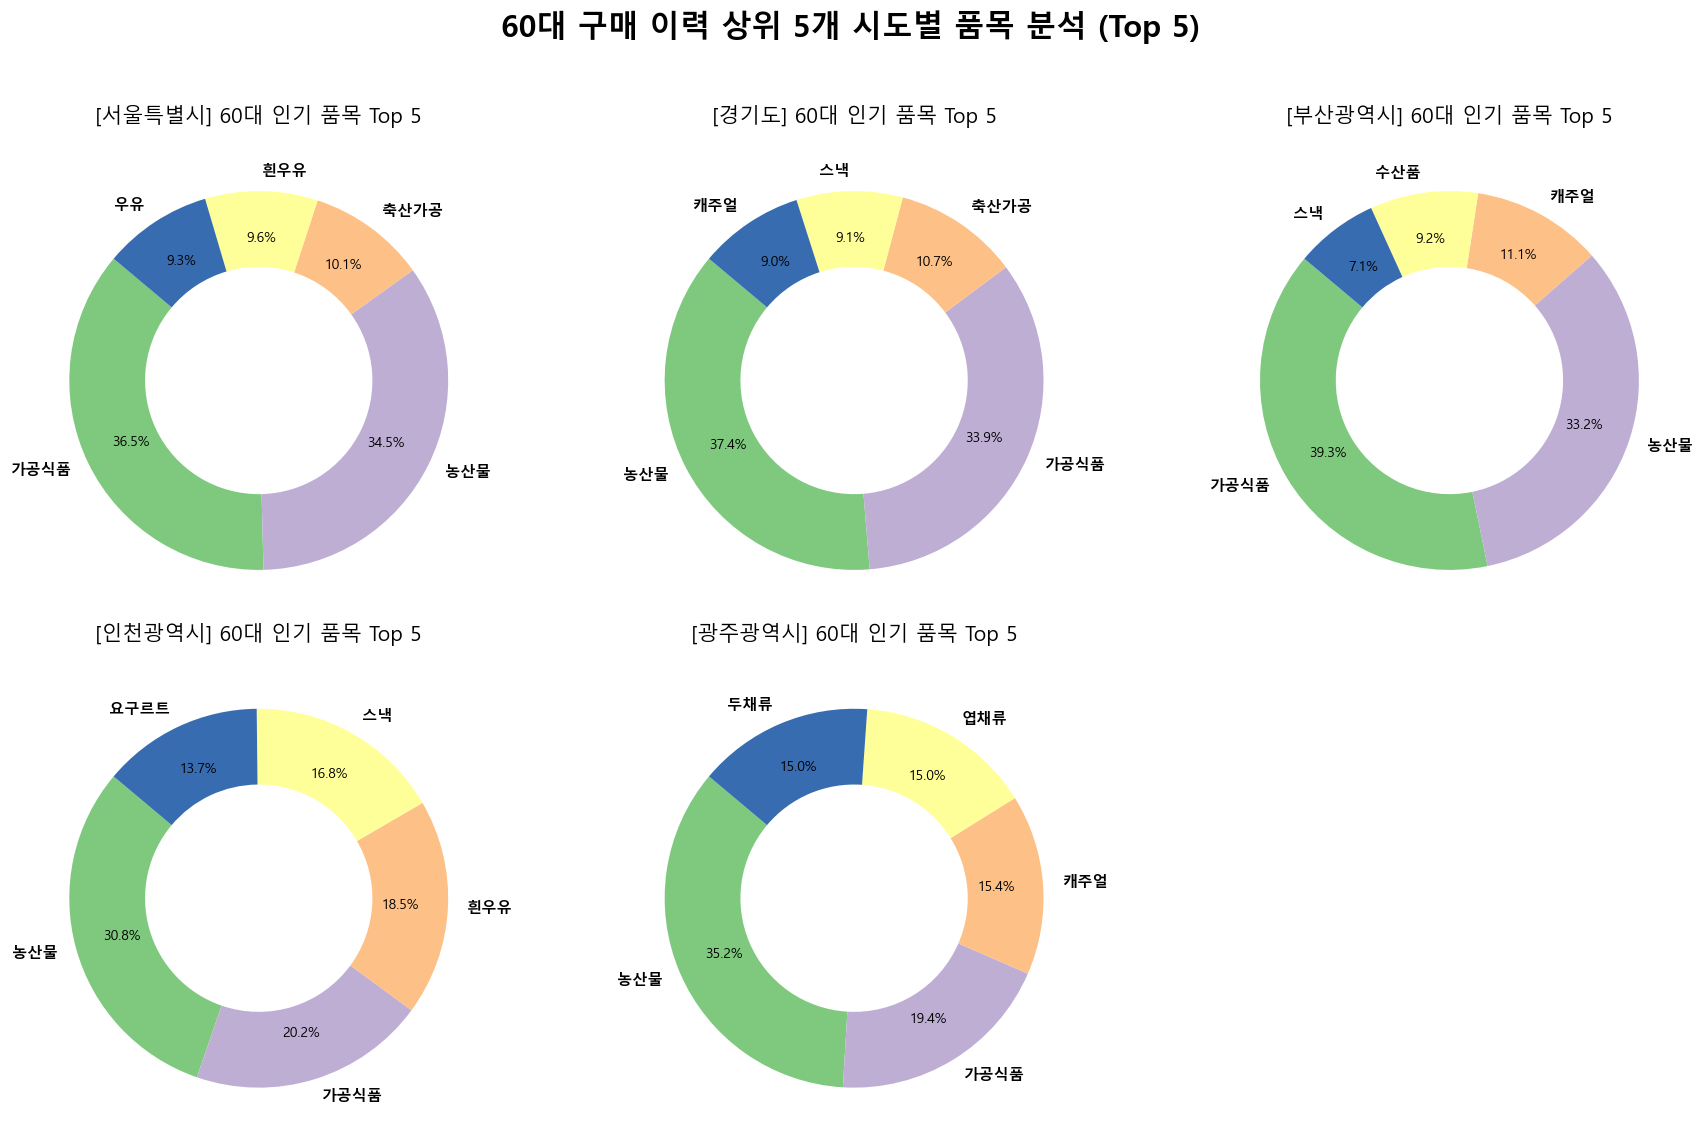

In [77]:
# 2. 60대 데이터 필터링 (이미지상 명칭인 '60세이상' 사용)
# 만약 데이터프레임의 값이 '60대'라면 '60대'로 수정하세요.
res_60 = result[result['연령구분'].str.contains('60')]

# 3. 60대 총 구매 건수 기준 상위 5개 시도 리스트 추출
top5_sido_60 = res_60.groupby('시도')['count'].sum().sort_values(ascending=False).head(5).index

# 4. 시각화 설정 (2행 3열 레이아웃)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() 

for i, sido in enumerate(top5_sido_60):
    # 해당 시도의 60대 데이터 중 품목 상위 5개 추출
    df_plot = res_60[res_60['시도'] == sido].sort_values('count', ascending=False).head(5)
    
    # 도넛 차트 그리기
    wedges, texts, autotexts = axes[i].pie(
        df_plot['count'], 
        labels=df_plot['중분류명'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=plt.cm.Accent.colors, # 40대와 구분하기 위해 색상 테마 변경
        pctdistance=0.75,
        wedgeprops={'width': 0.4} 
    )
    
    # 텍스트 스타일 조정
    plt.setp(texts, size=11, fontweight='bold')
    plt.setp(autotexts, size=10, color='black')
    
    axes[i].set_title(f'[{sido}] 60대 인기 품목 Top 5', fontsize=15, pad=15)

# 사용하지 않는 마지막 6번째 서브플롯(빈 칸) 삭제
fig.delaxes(axes[5])

plt.suptitle('60대 구매 이력 상위 5개 시도별 품목 분석 (Top 5)', fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [17]:
# 소분류명 기준으로 다시 집계 (기존 중분류명 대신 소분류명 사용)
result_sub = final.groupby(['시도', '연령구분'])['소분류명'].value_counts().groupby(level=[0, 1]).head(5).reset_index(name='count')

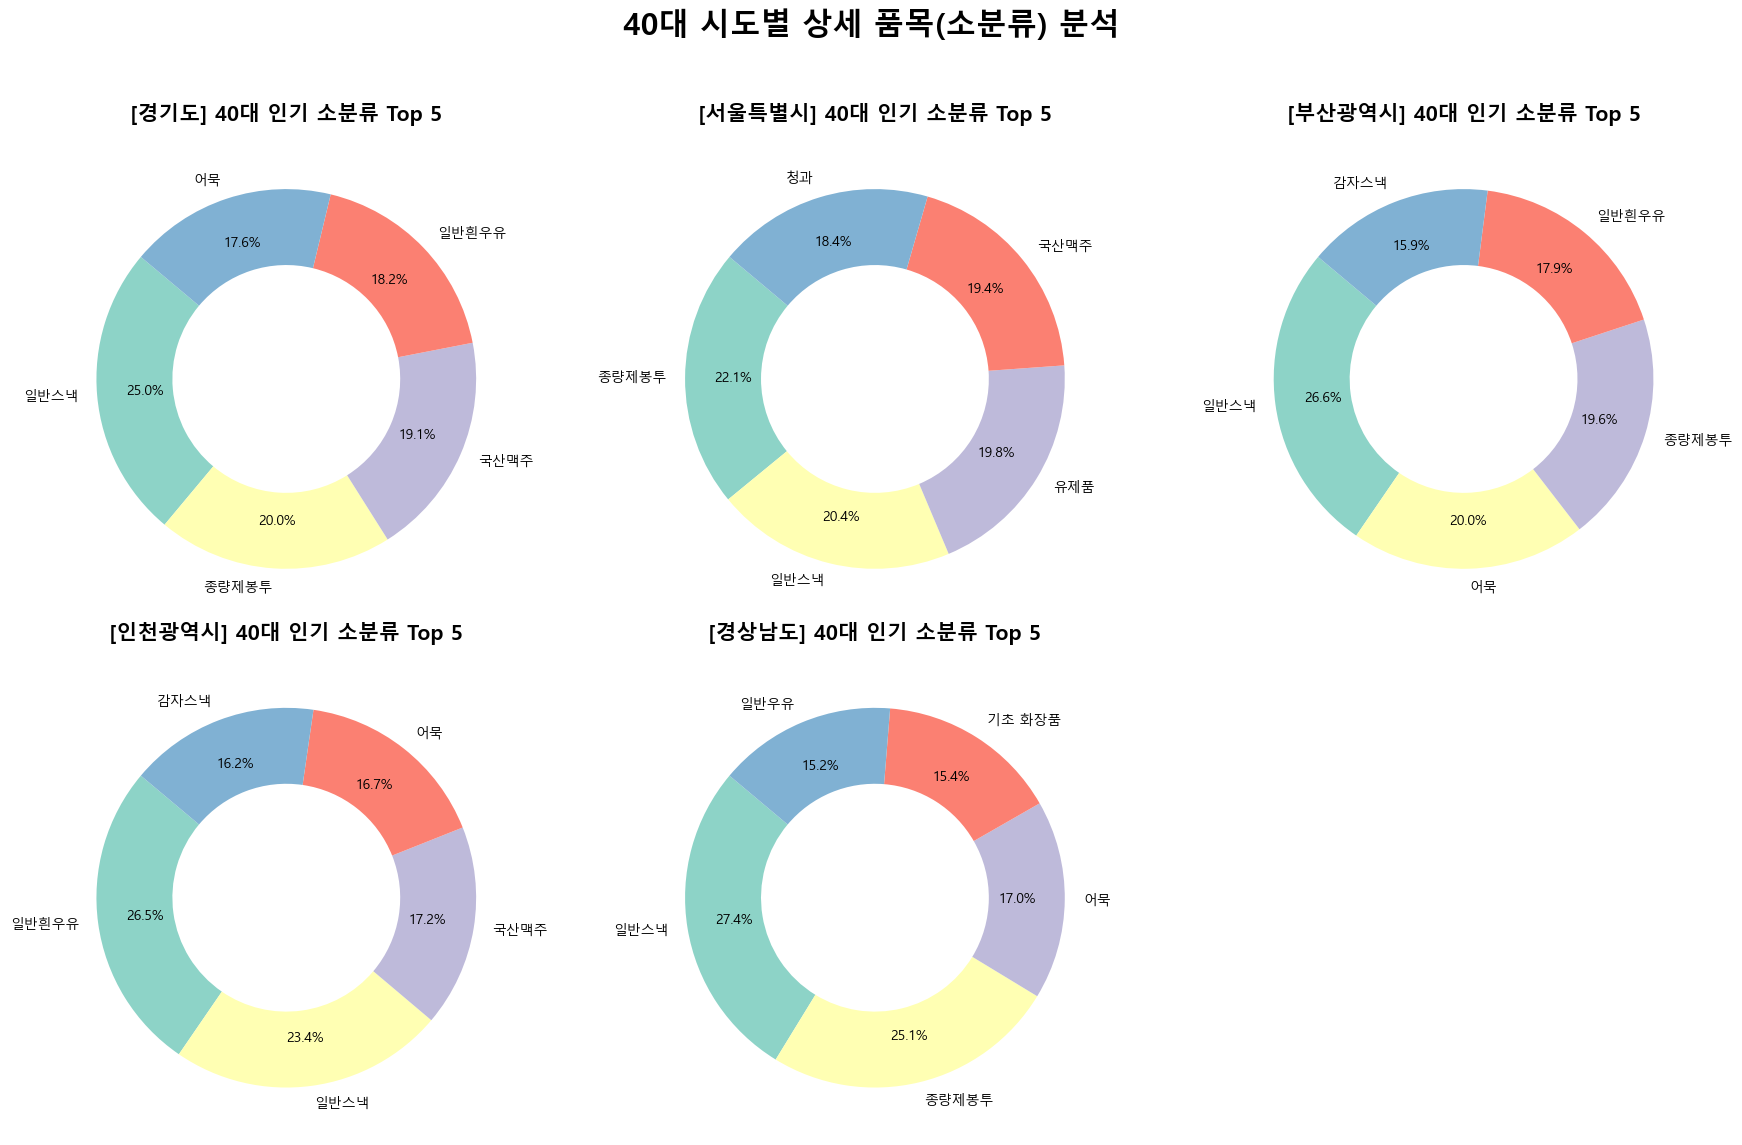

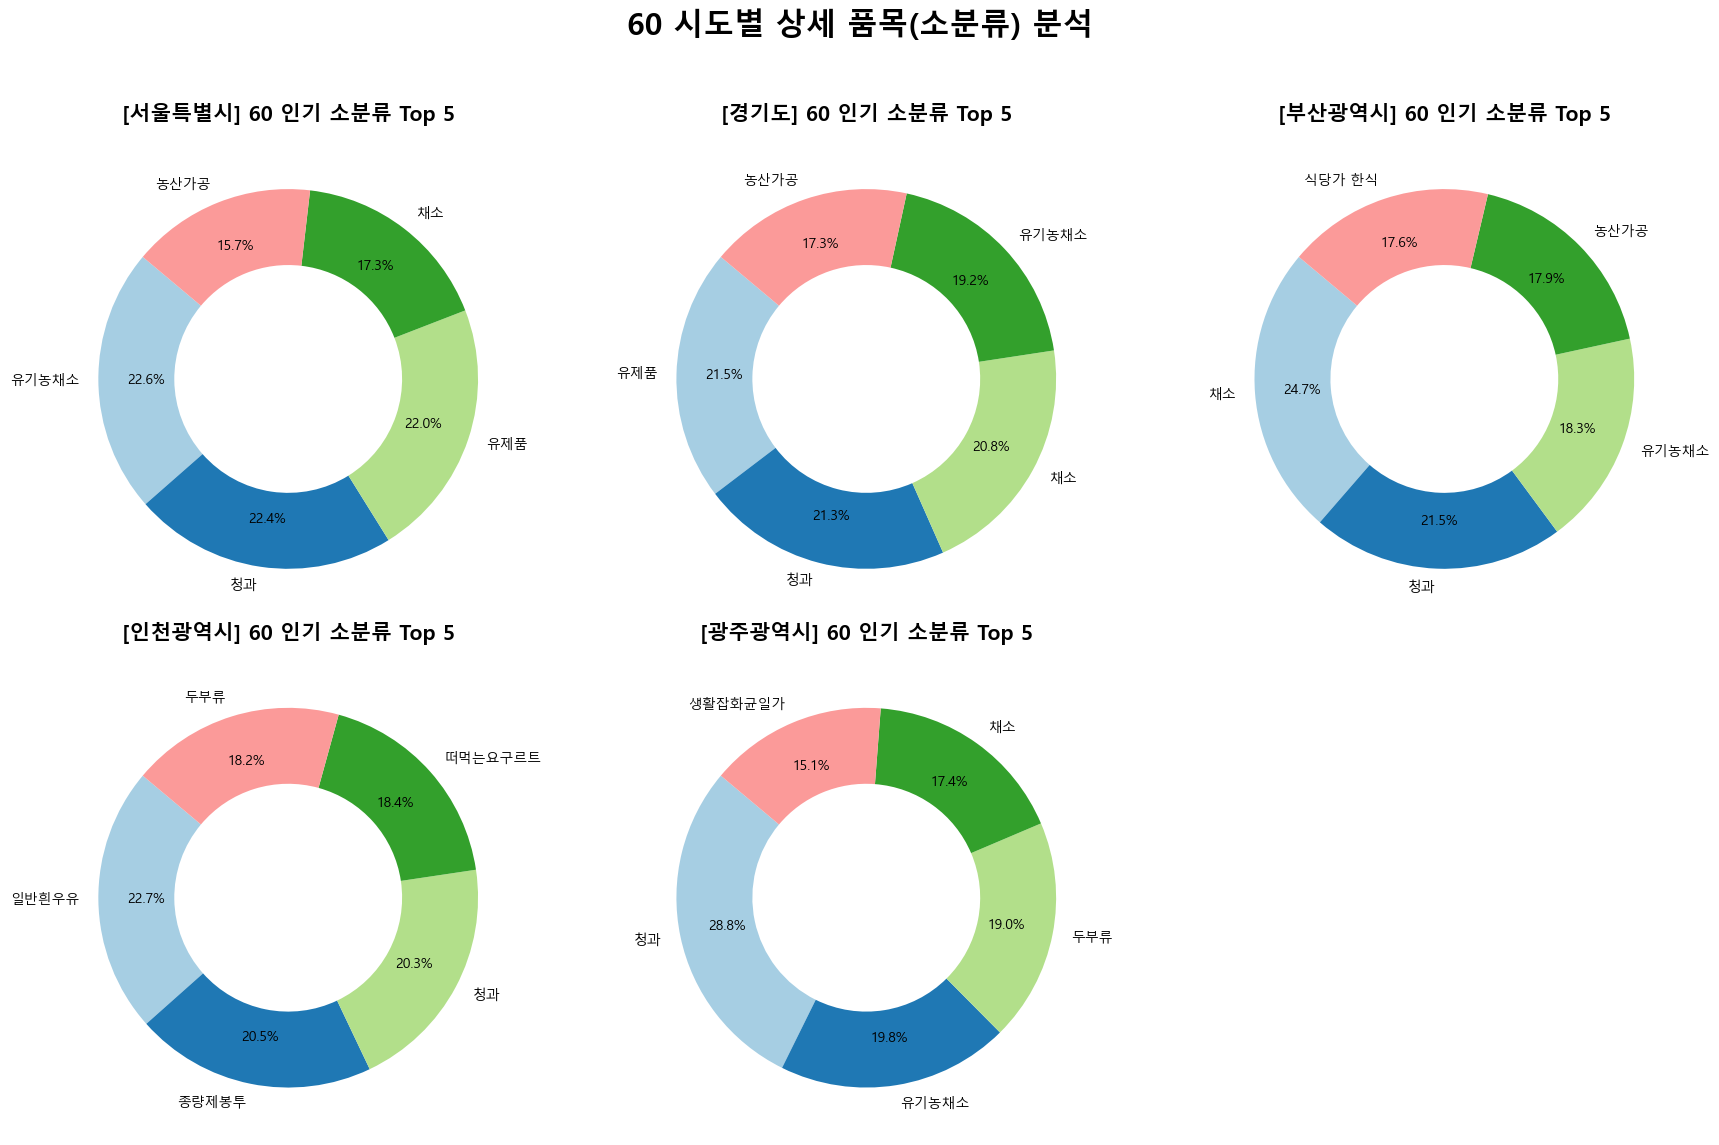

In [76]:
def plot_sub_category_donut(df_source, age_text, color_theme):
    # 1. 해당 연령대 필터링
    res_age = df_source[df_source['연령구분'].str.contains(age_text)]
    
    # 2. 해당 연령대 총 구매건수 상위 5개 시도 추출
    top5_sido = res_age.groupby('시도')['count'].sum().sort_values(ascending=False).head(5).index
    
    # 3. 시각화 설정 (2행 3열)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for i, sido in enumerate(top5_sido):
        # 해당 시도의 소분류 상위 5개 추출
        df_plot = res_age[res_age['시도'] == sido].sort_values('count', ascending=False).head(5)
        
        # 도넛 차트
        axes[i].pie(
            df_plot['count'], 
            labels=df_plot['소분류명'], 
            autopct='%1.1f%%', 
            startangle=140, 
            colors=color_theme,
            pctdistance=0.75,
            wedgeprops={'width': 0.4}
        )
        
        axes[i].set_title(f'[{sido}] {age_text} 인기 소분류 Top 5', fontsize=15, pad=15, fontweight='bold')

    # 빈 칸 삭제
    fig.delaxes(axes[5])
    
    plt.suptitle(f'{age_text} 시도별 상세 품목(소분류) 분석', fontsize=22, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- 실행 ---
# 40대 소분류 차트
plot_sub_category_donut(result_sub, "40대", plt.cm.Set3.colors)

# 60대 소분류 차트 (명칭이 '60세이상'인 경우 "60"으로 필터링)
plot_sub_category_donut(result_sub, "60", plt.cm.Paired.colors)

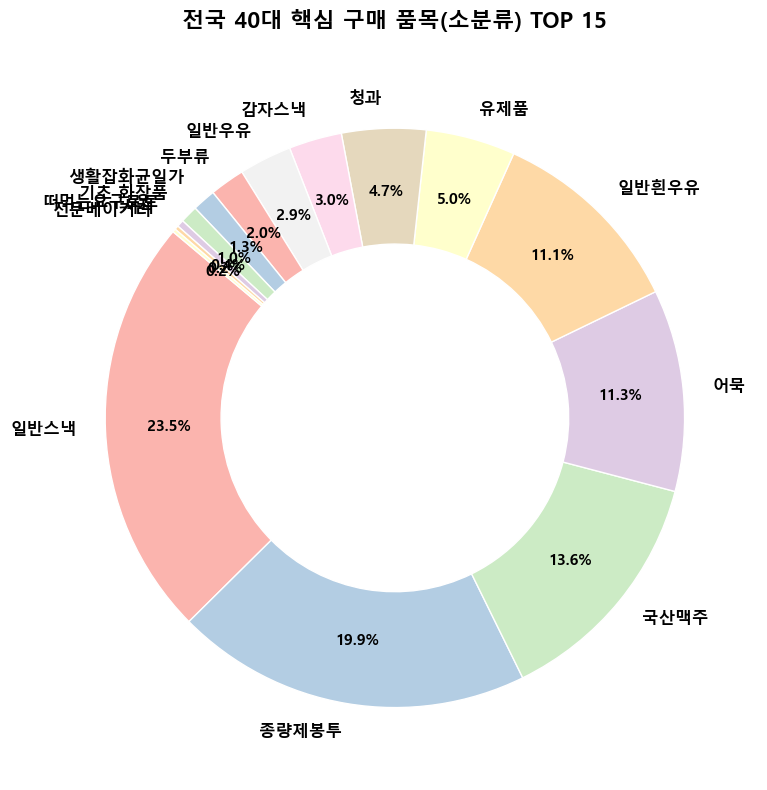

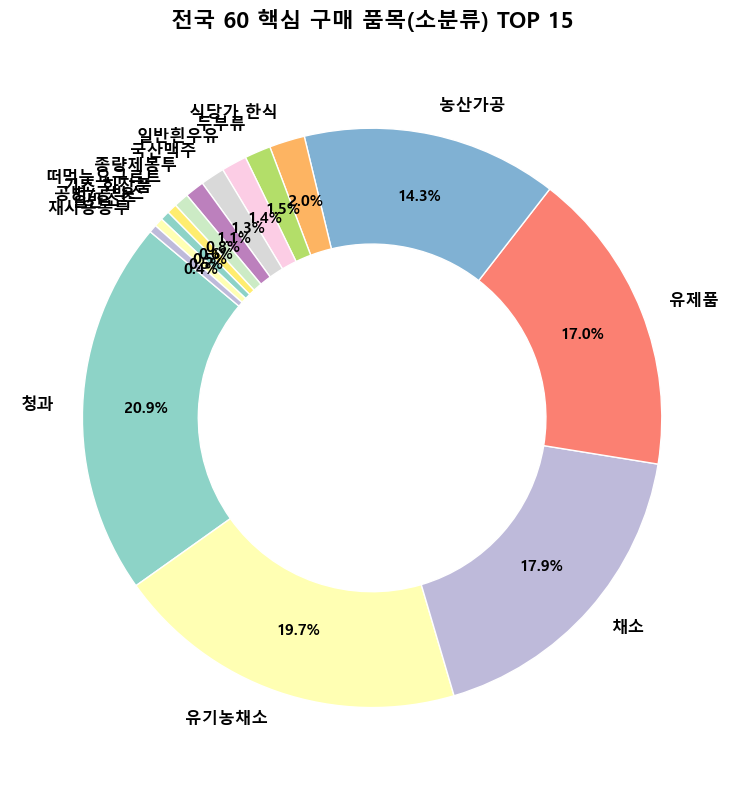

In [69]:
# 2. 전국 통합 집계 함수 정의
def plot_total_age_donut(df_source, age_text, color_theme):
    # 해당 연령대 필터링
    res_age = df_source[df_source['연령구분'].str.contains(age_text)]
    
    # 전국 단위로 품목(소분류명) 합산
    total_items = res_age.groupby('소분류명')['count'].sum().sort_values(ascending=False).head(15)
    
    # 그래프 그리기
    plt.figure(figsize=(8, 8))
    
    # 도넛 차트 설정
    wedges, texts, autotexts = plt.pie(
        total_items, 
        labels=total_items.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=color_theme,
        pctdistance=0.78,
        wedgeprops={'width': 0.4, 'edgecolor': 'w'}
    )
    
    # 텍스트 스타일
    plt.setp(texts, size=12, fontweight='bold')
    plt.setp(autotexts, size=11, fontweight='bold')
    
    plt.title(f'전국 {age_text} 핵심 구매 품목(소분류) TOP 15', fontsize=16, pad=20, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- 실행 ---

# 1. 40대 전국 통합 차트
plot_total_age_donut(result_sub, "40대", plt.cm.Pastel1.colors)

# 2. 60대 전국 통합 차트
plot_total_age_donut(result_sub, "60", plt.cm.Set3.colors)

In [25]:
pwd

'C:\\Users\\User\\Desktop\\pandas'

gdf head before filtering:


,code,name,name_eng,base_year,geometry
0,11250,강동구,Gangdong-gu,2013,"POLYGON ((127.1152 37.55753, 127.1188 37.55722..."
1,11240,송파구,Songpa-gu,2013,"POLYGON ((127.06907 37.52228, 127.07496 37.520..."
2,11230,강남구,Gangnam-gu,2013,"POLYGON ((127.05867 37.5263, 127.06907 37.5222..."
3,11220,서초구,Seocho-gu,2013,"POLYGON ((127.01397 37.52504, 127.01918 37.520..."
4,11210,관악구,Gwanak-gu,2013,"POLYGON ((126.98368 37.47386, 126.98464 37.469..."


Unique 'name' values in gdf (first 50):


<StringArray>
[ '강동구',  '송파구',  '강남구',  '서초구',  '관악구',  '동작구', '영등포구',  '금천구',  '구로구',
  '강서구',  '양천구',  '마포구', '서대문구',  '은평구',  '노원구',  '도봉구',  '강북구',  '성북구',
  '중랑구', '동대문구',  '광진구',  '성동구',  '용산구',   '중구',  '종로구']
Length: 25, dtype: str

Type of 'name' column: str
Length of gdf_seoul after filtering: 25
gdf_seoul 'name' column unique values (first 10):


...

,code,name,name_eng,base_year,geometry,gu,power
0,11250,강동구,Gangdong-gu,2013,"POLYGON ((127.1152 37.55753, 127.1188 37.55722...",강동구,2200
1,11240,송파구,Songpa-gu,2013,"POLYGON ((127.06907 37.52228, 127.07496 37.520...",송파구,2470
2,11230,강남구,Gangnam-gu,2013,"POLYGON ((127.05867 37.5263, 127.06907 37.5222...",강남구,2800
3,11220,서초구,Seocho-gu,2013,"POLYGON ((127.01397 37.52504, 127.01918 37.520...",서초구,2750
4,11210,관악구,Gwanak-gu,2013,"POLYGON ((126.98368 37.47386, 126.98464 37.469...",관악구,1810


gdf_merged 'power' column unique values (if any):


array([2200, 2470, 2800, 2750, 1810, 2280, 2410, 1760, 1940, 2100, 2260,
       2320, 2050, 1920, 1950, 1820, 1780, 2010, 1880, 1970, 2300, 2480,
       2720, 2650, 2390])


gdf_merged info prior to plotting:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   code       25 non-null     str     
 1   name       25 non-null     str     
 2   name_eng   25 non-null     str     
 3   base_year  25 non-null     str     
 4   geometry   25 non-null     geometry
 5   gu         25 non-null     str     
 6   power      25 non-null     int64   
dtypes: geometry(1), int64(1), str(5)
memory usage: 1.5 KB

Null values in gdf_merged prior to plotting:


code         0
name         0
name_eng     0
base_year    0
geometry     0
gu           0
power        0
dtype: int64

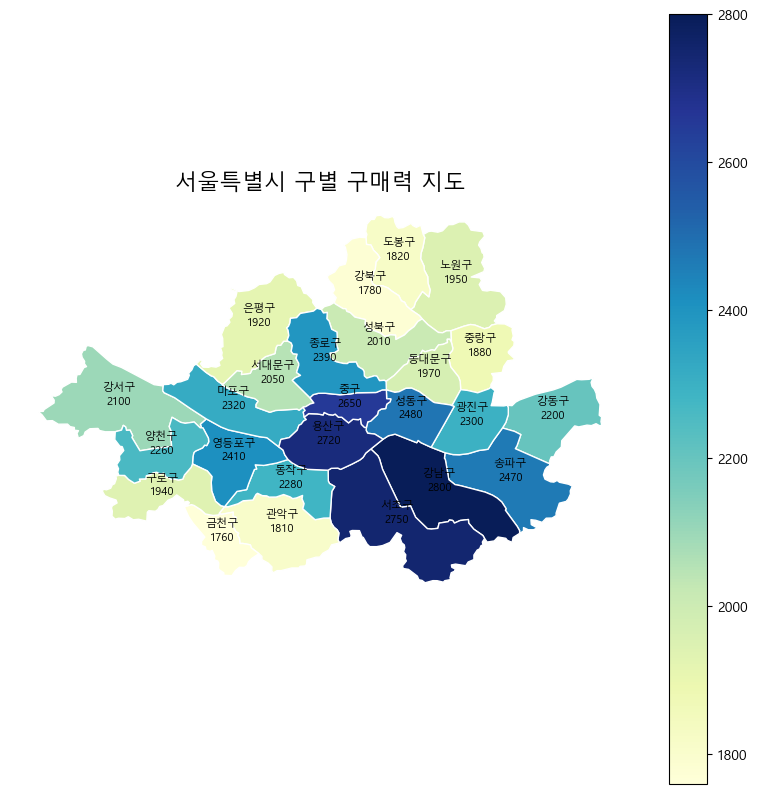

In [30]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Configure font for Korean characters (moved to the font installation cell 2e82023c)
# plt.rc('font', family='NanumGothic')
# plt.rcParams['axes.unicode_minus'] = False

# 1️⃣ 서울 구 GeoJSON 파일 불러오기
import folium
import requests
import json

# 1. 원본 파일보다 훨씬 가벼운(Simplified) 데이터 주소로 변경
# geo_url = 'https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2013/json/skorea_provinces_geo_simple.json'

# # 2. 데이터를 안전하게 불러와서 JSON으로 변환
# response = requests.get(geo_url)
# geo_data = response.json() # 여기서 에러가 안 나면 성공!

# # 3. 지도 시각화 (기존 코드 유지)
# m = folium.Map(location=[36.5, 127.5], zoom_start=7)
# folium.Choropleth(
#     geo_data=geo_data, # 불러온 변수를 직접 넣음
#     data=sido_data,    #  final2에서 집계한 데이터
#     columns=['시도', '구매건수'],
#     key_on='feature.properties.name',
#     fill_color='Blues',
# ).add_to(m)

gdf = gpd.read_file("https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json")

print("gdf head before filtering:")
display(gdf.head())
print("Unique 'name' values in gdf (first 50):")
display(gdf['name'].unique()[:50])
print("Type of 'name' column:", gdf['name'].dtype)

# 2️⃣ 구매력 데이터 (예시)
data = pd.DataFrame({
    'gu': [
        '강남구','서초구','송파구','강동구','마포구','용산구','성동구',
        '광진구','중구','종로구','동대문구','중랑구','성북구','강북구',
        '도봉구','노원구','은평구','서대문구','양천구','강서구',
        '구로구','영등포구','동작구','관악구','금천구'
    ],
    'power': [
        2800,2750,2470,2200,2320,2720,2480,
        2300,2650,2390,1970,1880,2010,1780,
        1820,1950,1920,2050,2260,2100,
        1940,2410,2280,1810,1760
    ]
})

# 3️⃣ 데이터 병합
# Filter gdf to include only Seoul 'gu's using the 'code' column and names from 'data'
# Seoul administrative codes typically start with '11'
gdf_seoul = gdf[
    (gdf['code'].astype(str).str.startswith('11')) & 
    (gdf['name'].isin(data['gu']))
].copy()

# The 'name' column in gdf_seoul already holds the 'gu' names, which matches 'gu' in 'data'.
gdf_merged = gdf_seoul.merge(data, left_on='name', right_on='gu', how='left')

print("Length of gdf_seoul after filtering:", len(gdf_seoul))
if not gdf_seoul.empty:
    print("gdf_seoul 'name' column unique values (first 10):")
    display(gdf_seoul['name'].unique()[:10])
    print("gdf_seoul head after filtering:")
    display(gdf_seoul.head())


print("Length of gdf_merged after merge:", len(gdf_merged))
if gdf_merged.empty:
    print("gdf_merged is empty. This means no matching 'gu' values were found or gdf_seoul was empty.")
    print("Unique 'name' in gdf_seoul:", gdf_seoul['name'].unique() if not gdf_seoul.empty else "gdf_seoul is empty")
    print("Unique 'gu' in data:", data['gu'].unique())
else:
    print("gdf_merged head after merge:")
    display(gdf_merged.head())
    print("gdf_merged 'power' column unique values (if any):")
    display(gdf_merged['power'].unique())

# Debugging prints for gdf_merged before plotting
print("\ngdf_merged info prior to plotting:")
gdf_merged.info()
print("\nNull values in gdf_merged prior to plotting:")
display(gdf_merged.isnull().sum())

# 4️⃣ 지도 그리기
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_merged.plot(
    column='power',
    cmap='YlGnBu',      # 색상
    linewidth=1,
    edgecolor='white',
    legend=True,
    ax=ax,
    aspect='equal',
    missing_kwds={
        "color": "lightgrey",
        "label": "데이터 없음"
    }
)

# 5️⃣ 구 이름 + 값 표시
for idx, row in gdf_merged.iterrows():
    if pd.notna(row['power']): # 'power' 값이 있는 경우에만 텍스트 표시
        plt.text(
            row.geometry.centroid.x,
            row.geometry.centroid.y,
            f"{row['gu']}\n{row['power']}",
            fontsize=8,
            ha='center'
        )

# 6️⃣ 제목
plt.title("서울특별시 구별 구매력 지도", fontsize=16)

# 7️⃣ 축 제거
plt.axis('off')

plt.show() 

In [21]:
!pip install geopandas

   ---------------------------------------- 0.0/23.6 MB ? eta -:--:--
   ---------------- ----------------------- 9.4/23.6 MB 44.0 MB/s eta 0:00:01
   ------------------------------------ --- 21.2/23.6 MB 49.5 MB/s eta 0:00:01
   ---------------------------------------- 23.6/23.6 MB 42.6 MB/s  0:00:00
   ---------------------------------------- 0.0/6.4 MB ? eta -:--:--
   ---------------------------------------- 6.4/6.4 MB 49.6 MB/s  0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 40.7 MB/s  0:00:00

   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   ---------------------------------------- 0/4 [shapely]
   -


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\User\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [44]:
df_target = final.groupby('시도')['시도'].value_counts().reset_index('시도')
df_target

,시도,count
0,강원특별자치도,328030
1,경기도,9048040
2,경상남도,1228414
3,경상북도,571055
4,광주광역시,972738
5,대구광역시,487676
6,대전광역시,560302
7,부산광역시,2533161
8,서울특별시,8181992
9,세종특별자치시,49051


In [45]:
# 1. 이미지에 있는 리스트 순서 그대로 정의
custom_order = [
    "서울특별시", "부산광역시", "대구광역시", "인천광역시", "광주광역시", 
    "대전광역시", "울산광역시", "세종특별자치시", "경기도", "강원특별자치도", 
    "충청북도", "충청남도", "전북특별자치도", "전라남도", "경상북도", "경상남도", "제주특별자치도"
]

# 2. '시도' 컬럼을 위 리스트 순서대로 '범주형(Categorical)' 데이터로 변환
# (df_target은 앞에서 전처리한 데이터프레임입니다)
df_target['시도'] = pd.Categorical(df_target['시도'], categories=custom_order, ordered=True)

# 3. 이제 sort_values를 하면 사용자가 지정한 리스트 순서대로 정렬됩니다.
df_sorted = df_target.sort_values('시도')

df_sorted
# 4. (참고) 지도 좌표(locs) 사전도 이 순서대로 재정렬하여 사용하면 
# 반복문을 돌릴 때 서울부터 순서대로 마커가 생성됩니다.
# locs_sorted = {name: locs[name] for name in custom_order if name in locs}

,시도,count
8,서울특별시,8181992
7,부산광역시,2533161
5,대구광역시,487676
11,인천광역시,1731212
4,광주광역시,972738
6,대전광역시,560302
10,울산광역시,230737
9,세종특별자치시,49051
1,경기도,9048040
0,강원특별자치도,328030


In [47]:
list(df_sorted['count'])

[8181992,
 2533161,
 487676,
 1731212,
 972738,
 560302,
 230737,
 49051,
 9048040,
 328030,
 619727,
 406766,
 824423,
 597779,
 571055,
 1228414,
 16988]

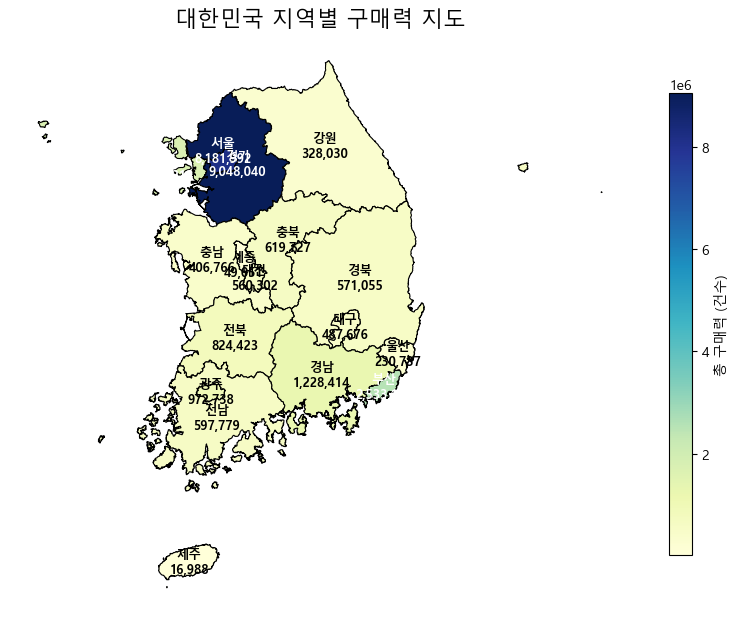

In [66]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


# 대한민국 시도 GeoJSON (공공 데이터)
geo_url = "https://raw.githubusercontent.com/southkorea/southkorea-maps/master/kostat/2018/json/skorea-provinces-2018-geo.json"
gdf = gpd.read_file(geo_url)

# 구매력 데이터 (단위: 만원/인)
data = {
    "name": [
        "서울특별시","부산광역시","대구광역시","인천광역시","광주광역시",
        "대전광역시","울산광역시","세종특별자치시",
        "경기도","강원도","충청북도","충청남도",
        "전라북도","전라남도","경상북도","경상남도","제주특별자치도"
    ],

    
    "value":list(df_sorted['count'])
}

df = pd.DataFrame(data)

# 데이터 병합
gdf = gdf.merge(df, how="left", left_on="name", right_on="name")

# 지도 그리기
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

gdf.plot(
    column="value",
    cmap="YlGnBu",   # 색상 (이미지와 유사)
    linewidth=0.8,
    edgecolor="black",
    legend=True,
    ax=ax, legend_kwds={'label': "총 구매력 (건수)", 'shrink': 0.5}
)

short_name = {
    "서울특별시": "서울", "부산광역시": "부산", "대구광역시": "대구", "인천광역시": "인천",
    "광주광역시": "광주", "대전광역시": "대전", "울산광역시": "울산", "세종특별자치시": "세종",
    "경기도": "경기", "강원도": "강원", "충청북도": "충북", "충청남도": "충남",
    "전라북도": "전북", "전라남도": "전남", "경상북도": "경북", "경상남도": "경남", "제주특별자치도": "제주"
}

# 5. 텍스트 배치 및 겹침 방지 로직
for idx, row in gdf.iterrows():
    centroid = row['geometry'].centroid
    x, y = centroid.x, centroid.y
    
    # 지역 이름을 짧게 변경
    display_name = short_name.get(row['name'], row['name'])
    label_text = f"{display_name}\n{row['value']:,.0f}" # 소수점 없이 정수로 표기 시 가독성 UP

    # --- 밀집 지역 위치 미세 조정 (서울, 인천 등 겹침 방지) ---
    if display_name == "서울": y += 0.12  # 위로 살짝 이동
    elif display_name == "인천": x -= 0.15; y -= 0.1 # 왼쪽 아래로
    elif display_name == "세종": y -= 0.08 # 아래로 살짝
    # ---------------------------------------------------

    color = 'white' if row['value'] > gdf['value'].mean() else 'black'
    
    ax.annotate(
        text=label_text, 
        xy=(x, y), 
        fontsize=9,        # 폰트 크기를 살짝 줄임
        fontweight='bold',
        ha='center', 
        va='center',
        color=color,
        # 흰색 테두리를 넣어 글자를 선명하게
        # path_effects=[plt.withStroke(linewidth=2, foreground='white' if color=='black' else 'black', alpha=0.3)]
    )


# 제목
plt.title("대한민국 지역별 구매력 지도", fontsize=16)

# 축 제거
ax.axis("off")

plt.show()

In [76]:
import seaborn as sns

# 요일/시간별 데이터 피벗
heatmap_data = purchase_40.groupby(['요일', '시간']).size().unstack()
heatmap_data = heatmap_data.reindex(['월', '화', '수', '목', '금', '토', '일'])

plt.figure(figsize=(16, 7))
sns.heatmap(heatmap_data, cmap="YlOrRd", annot=False, linewidths=.5)
plt.title("40대 라이프사이클: 언제 지갑을 가장 많이 열까?", fontsize=20, pad=20)
plt.xlabel("시간 (Hour)", fontsize=12)
plt.ylabel("요일 (Day)", fontsize=12)
plt.show()

NameError: name 'purchase_40' is not defined